In [1]:
import numpy as np
import matplotlib.pyplot as plt
from define_data_and_variables import get_data, get_hmc_config
import arviz as az
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import os
import gc
from pathlib import Path
from define_data_and_variables import adam_config, pt_config, data, adam_hash, hash_configs
import json

# TODO: fix so that it is easy to run either with fixed dF or updating dF. Need to increase maximum temp. Maybe increase number of shared chains for this as well.:)


In [2]:
base_dir = Path.cwd()
adam_config_ee = adam_config
adam_config_ee["mi"] = 10000
adam_hash_ee = hash_configs(adam_config_ee, data)

adam_dir = base_dir / f"output/{data["dn"]}/{adam_hash}"
adam_dir_ee = base_dir / f"output/{data['dn']}/{adam_hash_ee}"

starting_points = np.load(adam_dir / "adam_samples.npy")
energies = np.load(adam_dir / "adam_energies.npy")

indices = np.argsort(energies)
sp = starting_points[indices][:pt_config["nt"]]
pt_config["hmcc"]["sp"] = np.ascontiguousarray(sp)

pt_hash = hash_configs(pt_config, data)
output_dir = adam_dir / f"{pt_hash}"

hmc_config = pt_config["hmcc"]

In [3]:
colors = plt.cm.viridis(np.linspace(0, 1, pt_config["nt"]))

In [4]:
def expected_ages(N, delta_c, cs, theta, num_depths, depths, sed_rates, indices):
    cumulative_sum_vec = [0.0] * (N + 1)
    
    # Build cumulative sum vector
    for i in range(1, N + 1):
        cumulative_sum_vec[i] = cumulative_sum_vec[i - 1] + sed_rates[i - 1] * delta_c
    
    ages_out = [0.0] * num_depths
    
    # Compute ages
    for i in range(num_depths):
        index = indices[i]
        cumulative_sum = cumulative_sum_vec[index]
        cumulative_sum += sed_rates[index] * (depths[i] - cs[index])
        ages_out[i] = theta - cumulative_sum
    
    return ages_out


def get_index(N, cs, c14_depths, depth_index):
    low, high = 0, N - 1
    target = c14_depths[depth_index]
    
    while low <= high:
        mid = (low + high) // 2
        if cs[mid] < target:
            low = mid + 1
        else:
            high = mid - 1
    
    return low - 1 if low > 0 else 0

(5, 51)


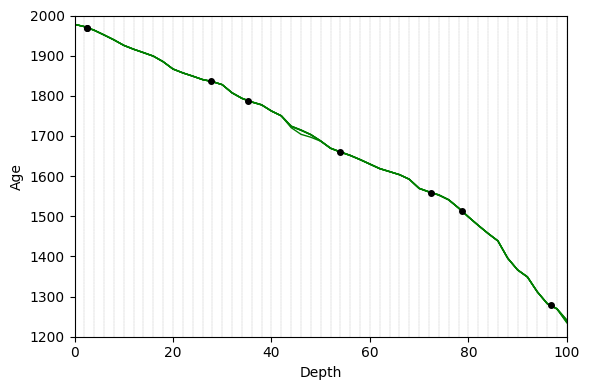

In [5]:

cumulative_sums = np.cumsum(sp, axis=1) * data["dc"]
zeros = np.zeros((*sp.shape[:1], 1))
age_offsets = np.concatenate((zeros, cumulative_sums), axis=1)
print(np.shape(age_offsets))

model_ages = data["th"] - age_offsets

# Age depth trace plot
fig, ax = plt.subplots(figsize=(6, 4))
num_samples = len(sp)
for j in range(num_samples):
    ax.plot(
        data["cs"],
        model_ages[j, :],
        color='green',
        alpha=1,
        linewidth=1,
    )
for i, c in enumerate(data["cs"]):
    ax.axvline(x=c, color='k', linestyle='--', linewidth = 0.1)

ax.set_xlim(0, np.max(data["cs"]))
ax.set_ylim(1200, 2000)
plt.plot(data["c14d"], np.squeeze(data["c14"]), "ko", markersize=4)
# plt.plot(config["cs"], data["theta"] - config["dc"] * np.cumsum((config["a"]/config["b"]) * np.ones_like(config["cs"])), color = 'k', linewidth=0.5)
plt.xlabel("Depth")
plt.ylabel("Age")
plt.tight_layout()
plt.savefig(f"{adam_dir}/sp_age_depth.jpg")
plt.show()

(100, 51)


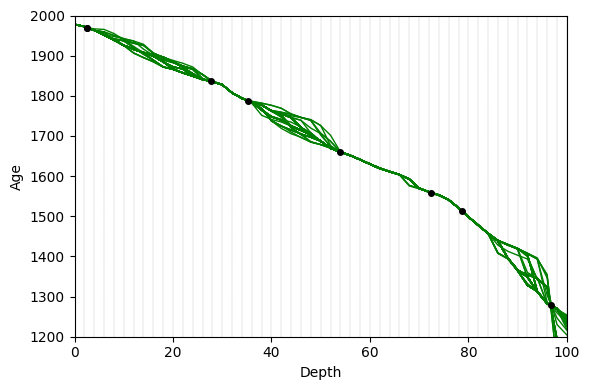

In [6]:

cumulative_sums = np.cumsum(starting_points, axis=1) * data["dc"]
zeros = np.zeros((*starting_points.shape[:1], 1))
age_offsets = np.concatenate((zeros, cumulative_sums), axis=1)
print(np.shape(age_offsets))

model_ages = data["th"] - age_offsets

# Age depth trace plot
fig, ax = plt.subplots(figsize=(6, 4))
num_samples = len(starting_points)
for j in range(num_samples):
    ax.plot(
        data["cs"],
        model_ages[j, :],
        color='green',
        alpha=1,
        linewidth=1,
    )
for i, c in enumerate(data["cs"]):
    ax.axvline(x=c, color='k', linestyle='--', linewidth = 0.1)

ax.set_xlim(0, np.max(data["cs"]))
ax.set_ylim(1200, 2000)
plt.plot(data["c14d"], np.squeeze(data["c14"]), "ko", markersize=4)
# plt.plot(config["cs"], data["theta"] - config["dc"] * np.cumsum((config["a"]/config["b"]) * np.ones_like(config["cs"])), color = 'k', linewidth=0.5)
plt.xlabel("Depth")
plt.ylabel("Age")
plt.tight_layout()
plt.savefig(f"{adam_dir}/all_sp_age_depth.jpg")
plt.show()

In [7]:
samples = np.load(output_dir / "samples.npy")

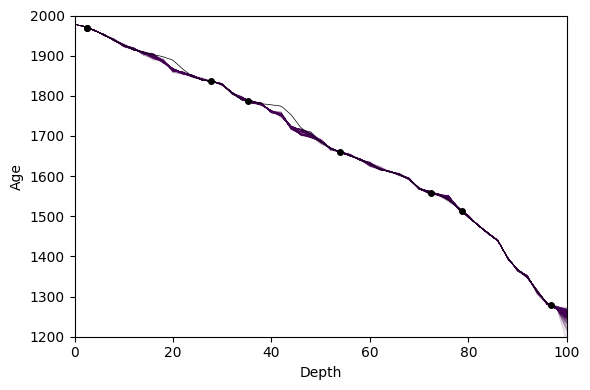

In [9]:
short_samples = samples[:, :, :]
cumulative_sums = np.cumsum(short_samples, axis=2) * data["dc"]
zeros = np.zeros((*short_samples.shape[:2], 1))
age_offsets = np.concatenate((zeros, cumulative_sums), axis=2)

model_ages = data["th"] - age_offsets

# Age depth trace plot
fig, ax = plt.subplots(figsize=(6, 4))
num_samples = len(short_samples[0,:,0])
# for i in range(pt_config["nt"]):
for j in range(num_samples):
    ax.plot(
        data["cs"],
        model_ages[0, j, :],
        color=colors[0],
        alpha=0.3,
        linewidth=0.1,
    )

ax.set_xlim(0, np.max(data["cs"]))
ax.set_ylim(1200, 2000)
plt.plot(data["c14d"], np.squeeze(data["c14"]), "ko", markersize=4)
plt.plot(data["d18od"], data["d18ota"], color = 'k', linewidth=0.5)
plt.xlabel("Depth")
plt.ylabel("Age")
plt.tight_layout()
plt.savefig(f"{output_dir}/age_depth_samples.jpg")
plt.show()

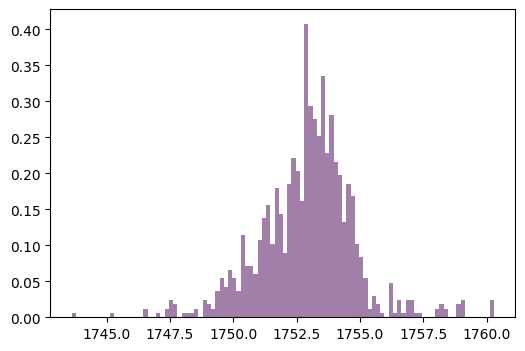

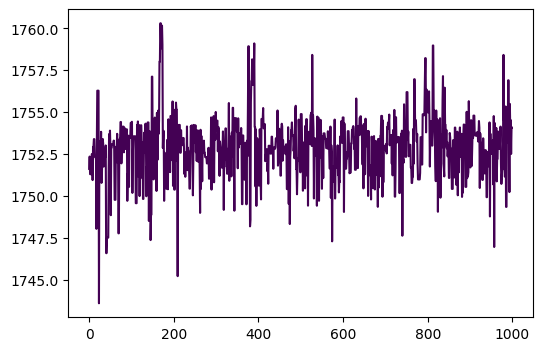

In [12]:
index = 21
interesting_depth = index * data["dc"]
CV_values = data["th"] - data["dc"] * np.sum(samples[0, :, :index], axis = 1)
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(CV_values, bins = 100, color = colors[0], label = f"chain {i}", alpha = 0.5, density = True)
plt.savefig(f"{output_dir}/samples_along_depth_{interesting_depth}.jpg")
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(CV_values, color = colors[0], label = f"chain {i}")
plt.savefig(f"{output_dir}/sampling_along_depth_evolution_{interesting_depth}.jpg")
plt.show()

In [ ]:
energy_values = np.load(f"{output_dir}/energy.npy")
d18o_energy_values = np.load(f"{output_dir}/d18o_energy.npy")

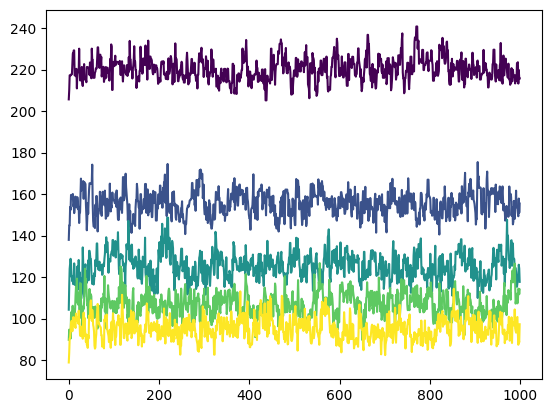

In [ ]:
plt.figure()
for i in range(pt_config["nt"]):
    plt.plot(energy_values[i,:] + (1 - pt_config["bs"][i])*d18o_energy_values[i, :], color = colors[i])
plt.savefig(f"{output_dir}/energy.jpg")
plt.show()

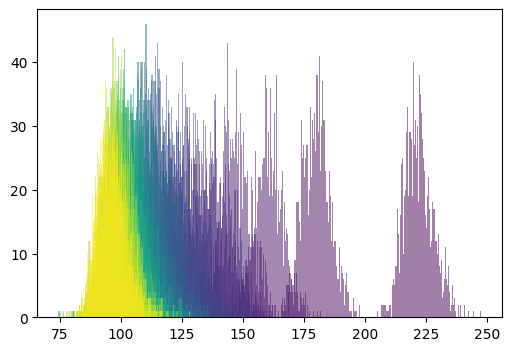

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
for i in range(pt_config["nt"]):
    ax.hist(energy_values[i, :], color = colors[i], alpha = 0.5, label = f"chain{i}", bins = 100)
# plt.legend()
plt.savefig(f"{output_dir}/energy_hist.jpg")
plt.show()   

In [ ]:
d18o_energy_values = np.load(f"{output_dir}/d18o_energy.npy")